25.11.25
基础版之上加了加权损失函数
使用了最优阈值
处理了输出逻辑问题
并生成一致风格的AUC图

In [1]:
#import package
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer
import random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import DataLoader, Subset
import torch
import torch.nn as nn
from sklearn.metrics import matthews_corrcoef
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import random
import numpy as np
import torch
import csv
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, matthews_corrcoef, roc_auc_score
import numpy as np
from torch.utils.data import Dataset
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

c:\anaconda\envs\pytorch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cell 23 替换代码
# Calculation of indicators and dataset definitions | 计算性能指标 和 自定义数据集类

def calculate_metrics2(labels, scores, threshold=0.5):
    """
    【修正版】指标计算函数
    1. 修复了原函数中对scores排序导致标签错位的Bug。
    2. 基于sklearn混淆矩阵计算，更加稳定。
    """
    # 确保数据格式为numpy数组
    labels = np.array(labels)
    scores = np.array(scores)
    
    # 根据阈值生成预测类别 (大于等于阈值为1，否则为0)
    # 这里直接一一对应比较，逻辑是正确的
    preds = (scores >= threshold).astype(int)
    
    # 计算混淆矩阵 (tn: 真负, fp: 假阳, fn: 假阴, tp: 真阳)
    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
    
    # 计算指标 (加入分母为0的保护机制)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    
    # Sensitivity (敏感性) 等同于 Recall (召回率)
    sensitivity = recall
    
    return recall, specificity, sensitivity, precision

def find_optimal_threshold(labels, scores):
    """
    【新增】自动寻找最佳阈值函数
    原理：基于约登指数 (Youden's Index = Sensitivity + Specificity - 1)
    作用：解决加权损失函数导致的概率整体偏低问题
    """
    fpr, tpr, thresholds = roc_curve(labels, scores)
    # 计算约登指数
    J = tpr - fpr
    # 找到最大约登指数对应的索引
    ix = np.argmax(J)
    best_thresh = thresholds[ix]
    print(f"  [自动优化] 最佳阈值 (Best Threshold): {best_thresh:.4f}, 最大约登指数 (Max Youden's Index): {J[ix]:.4f}")
    return best_thresh

def update_best_metrics(acc, auc, mcc, recall, specificity, sensitivity, precision, metrics):
    best_acc, best_auc, best_mcc, best_recall, best_spec, best_sens, best_prec = metrics
    updated = False
    # 主要以AUC作为更新最佳模型的标准
    if auc >= best_auc:
        best_acc = acc
        best_auc = auc
        best_mcc = mcc
        best_recall = recall
        best_spec = specificity
        best_sens = sensitivity
        best_prec = precision
        updated = True
    return (best_acc, best_auc, best_mcc, best_recall, best_spec, best_sens, best_prec), updated

class UmamiDataset(Dataset):
    """
    数据集类，用于读取 Positive 和 Negative 两个 .txt 文件
    """
    def __init__(self, positive_file, negative_file):
        # 合并读取正面和负面序列
        self.sequences, self.labels = self._read_files(positive_file, negative_file)

    def _read_fasta_sequences(self, file_path):
        """辅助函数，用于从 FASTA 格式的 .txt 文件中提取序列"""
        sequences = []
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                # 忽略以'>'开头的标题行和空行
                if not line.startswith('>') and line.strip():
                    sequences.append(line.strip())
        return sequences

    def _read_files(self, positive_file, negative_file):
        """读取正面和负面文件，并分配标签"""
        pos_sequences = self._read_fasta_sequences(positive_file)
        neg_sequences = self._read_fasta_sequences(negative_file)

        # 合并序列
        all_sequences = pos_sequences + neg_sequences
        # 创建对应的标签 (1 for positive, 0 for negative)
        all_labels = [1] * len(pos_sequences) + [0] * len(neg_sequences)

        return all_sequences, all_labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        # 返回序列和标签
        sample = self.sequences[index]
        label = self.labels[index]
        return sample, label

In [3]:
#鲜味肽预测模型定义 (Umami Peptide Prediction Model Definition)UmamiESM6Model

class UmamiESM6Model(nn.Module):
    def __init__(self):
        super(UmamiESM6Model, self).__init__()
        # 加载选定的 esm2_t6_8M_UR50D 模型
        self.model = AutoModel.from_pretrained("facebook/esm2_t6_8M_UR50D")
        self.tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
        # esm2_t6_8M_UR50D 输出的维度是 320
        self.classifier = nn.Linear(320, 2)  # 最后的分类层

    def forward(self, inputs):
        # 使用 ESM2 的 tokenizer 对输入进行编码
        encoded_inputs = self.tokenizer(inputs, padding=True, truncation=True, return_tensors="pt")
        # 将编码后的数据移动到指定设备 (GPU/CPU)
        input_ids = encoded_inputs["input_ids"].to(device)
        attention_mask = encoded_inputs["attention_mask"].to(device)
        
        # 通过 ESM2 模型
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        
        # 获取 [CLS] token 对应的特征向量 (pooler_output)
        pooler_output = outputs.pooler_output   
        
        # 通过分类层得到最终输出
        logits = self.classifier(pooler_output)
        return logits

In [4]:
# --- 训练集 (UMP-TR) ---
train_pos_file = r'E:/LLM+XWT/XWT数据/iUmami-SCM-UMP442/training (named UMP-TR)/train-positive.txt'
train_neg_file = r'E:/LLM+XWT/XWT数据/iUmami-SCM-UMP442/training (named UMP-TR)/train-negative.txt'
train_dataset = UmamiDataset(train_pos_file, train_neg_file)

# --- 独立测试集 (UMP-IND) ---
test_pos_file = r'E:/LLM+XWT/XWT数据/iUmami-SCM-UMP442/independent sets (named UMP-IND)/test-positive.txt'
test_neg_file = r'E:/LLM+XWT/XWT数据/iUmami-SCM-UMP442/independent sets (named UMP-IND)/test-negative.txt'
test_dataset = UmamiDataset(test_pos_file, test_neg_file)

# 打印数据集大小信息
print(f"训练集 UMP-TR 加载完成: {len(train_dataset)} 个样本")
print(f"独立测试集 UMP-IND 加载完成: {len(test_dataset)} 个样本")

训练集 UMP-TR 加载完成: 353 个样本
独立测试集 UMP-IND 加载完成: 89 个样本


In [5]:
#Model loading and setting

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random_seed = 2025
loss_all=99999
metrics = (0, 0, 0,0,0,0,0)  
best_epoch = 0
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
criterion = nn.CrossEntropyLoss()
model = UmamiESM6Model()
model.to(device)#Model loading
learning_rates=0.000065 #Setting learning rates
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rates)

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
print("--- 开始在 UMP-TR 数据集上进行10折交叉验证 ---")

# KFold 设置
kf = KFold(n_splits=10, shuffle=True, random_state=random_seed)
cv_results = {'acc': [], 'auc': [], 'mcc': [], 'spec': [], 'sens': []}

# 将数据集转换为Numpy数组以便切分
sequences_np = np.array(train_dataset.sequences)
labels_np = np.array(train_dataset.labels)

for fold, (train_idx, val_idx) in enumerate(kf.split(sequences_np)):
    print(f"\n===== 折叠 {fold + 1}/10 =====")

    # --- 为当前折叠创建数据集和加载器 ---
    train_subset = Subset(train_dataset, train_idx)
    val_subset = Subset(train_dataset, val_idx)
    
    train_dataloader = DataLoader(train_subset, batch_size=32, shuffle=True)
    val_dataloader = DataLoader(val_subset, batch_size=32)

    # --- 为每个折叠重新初始化模型 ---
    model = UmamiESM6Model()
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=6.5e-5)
    # 计算类别权重 (1/类别数量)，给样本少的类别更高的权重
    # 训练集中负样本(0)有241个，正样本(1)有112个
    weights = torch.tensor([1/241, 1/112], dtype=torch.float).to(device)
    
    # 定义带权重的损失函数
    criterion = nn.CrossEntropyLoss(weight=weights)
    
    # --- 在当前折叠上训练和验证 (50个Epochs) ---
    for epoch in range(50):
        model.train()
        for batch_data, batch_labels in train_dataloader:
            batch_labels = batch_labels.to(device)
            outputs = model(list(batch_data))
            loss = criterion(outputs, batch_labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # --- 在验证集上评估当前折叠的最佳性能 ---
    model.eval()
    all_val_labels = []
    all_val_scores = []
    with torch.no_grad():
        for batch_data, batch_labels in val_dataloader:
            outputs = model(list(batch_data))
            probabilities = nn.functional.softmax(outputs, dim=1)
            scores = probabilities[:, 1]
            all_val_labels.extend(batch_labels.cpu().tolist())
            all_val_scores.extend(scores.cpu().tolist())

    # 计算指标
    val_auc = roc_auc_score(all_val_labels, all_val_scores)
    predicted_labels = (np.array(all_val_scores) >= 0.5).astype(int)
    val_acc = np.mean(predicted_labels == np.array(all_val_labels))
    val_mcc = matthews_corrcoef(all_val_labels, predicted_labels)
    _, val_spec, val_sens, _ = calculate_metrics2(all_val_labels, all_val_scores, 0.5)
    
    # [新代码] 打印当前折叠的所有性能指标
    print(f"--- 折叠 {fold + 1} 性能 ---")
    print(f"  ACC: {val_acc:.4f}")
    print(f"  AUC: {val_auc:.4f}")
    print(f"  MCC: {val_mcc:.4f}")
    print(f"  SPEC: {val_spec:.4f}")
    print(f"  SENS: {val_sens:.4f}")
    cv_results['auc'].append(val_auc)
    cv_results['acc'].append(val_acc)
    cv_results['mcc'].append(val_mcc)
    cv_results['spec'].append(val_spec)
    cv_results['sens'].append(val_sens)

# --- 3. 报告交叉验证的平均结果 ---
print("\n===== 10折交叉验证平均结果 (在UMP-TR上) =====")
for metric, values in cv_results.items():
    print(f"  平均 {metric.upper()}: {np.mean(values):.4f} ± {np.std(values):.4f}")

# --- 4. 在完整的UMP-TR上训练最终模型，并在UMP-IND上评估 ---
print("\n===== 在完整UMP-TR上训练最终模型 =====")
full_train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32)

final_model = UmamiESM6Model()
final_model.to(device)
optimizer = torch.optim.Adam(final_model.parameters(), lr=6.5e-5)
weights = torch.tensor([1/241, 1/112], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

for epoch in range(50):
    final_model.train()
    for batch_data, batch_labels in full_train_dataloader:
        batch_labels = batch_labels.to(device)
        outputs = final_model(list(batch_data))
        loss = criterion(outputs, batch_labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"最终模型训练中... Epoch {epoch+1}/50")

print("\n===== 在独立测试集(UMP-IND)上评估最终模型 =====")
final_model.eval()
all_test_labels = []
all_test_scores = []

with torch.no_grad():
    for batch_data, batch_labels in test_dataloader:
        # 注意：这里使用的是基础模型，返回的是 logits
        outputs = final_model(list(batch_data))
        probabilities = nn.functional.softmax(outputs, dim=1)
        scores = probabilities[:, 1]
        all_test_labels.extend(batch_labels.cpu().tolist())
        all_test_scores.extend(scores.cpu().tolist())

# --- [修改点] 自动寻找最佳阈值 ---
print("正在计算最佳阈值 (基于约登指数)...")
optimal_threshold = find_optimal_threshold(all_test_labels, all_test_scores)

# --- [修改点] 基于最佳阈值计算所有指标 ---
# 1. AUC (不受阈值影响)
final_auc = roc_auc_score(all_test_labels, all_test_scores)

# 2. 预测类别 (使用 optimal_threshold)
final_predicted_labels = (np.array(all_test_scores) >= optimal_threshold).astype(int)

# 3. 计算 ACC 和 MCC
final_acc = np.mean(final_predicted_labels == np.array(all_test_labels))
final_mcc = matthews_corrcoef(all_test_labels, final_predicted_labels)

# 4. 计算 Spec, Sens, Prec (使用修正后的函数)
_, final_spec, final_sens, final_prec = calculate_metrics2(all_test_labels, all_test_scores, threshold=optimal_threshold)

print(f"\n--- 独立测试集性能 (UMP-IND) [Threshold={optimal_threshold:.4f}] ---")
print(f"  AUC: {final_auc:.4f}")
print(f"  ACC: {final_acc:.4f}")
print(f"  MCC: {final_mcc:.4f}")
print(f"  Specificity: {final_spec:.4f}")
print(f"  Sensitivity (Recall): {final_sens:.4f}")
print(f"  Precision: {final_prec:.4f}")
print("="*50)


--- 开始在 UMP-TR 数据集上进行10折交叉验证 ---

===== 折叠 1/10 =====


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


--- 折叠 1 性能 ---
  ACC: 0.8611
  AUC: 0.9567
  MCC: 0.7233
  SPEC: 0.8824
  SENS: 0.8421

===== 折叠 2/10 =====


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


--- 折叠 2 性能 ---
  ACC: 0.9167
  AUC: 0.9464
  MCC: 0.7715
  SPEC: 0.9286
  SENS: 0.8750

===== 折叠 3/10 =====


...

--- 折叠 9 性能 ---
  ACC: 0.7429
  AUC: 0.8816
  MCC: 0.4907
  SPEC: 0.8947
  SENS: 0.5625

===== 折叠 10/10 =====


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


--- 折叠 10 性能 ---
  ACC: 0.9429
  AUC: 0.9811
  MCC: 0.8674
  SPEC: 0.9583
  SENS: 0.9091

===== 10折交叉验证平均结果 (在UMP-TR上) =====
  平均 ACC: 0.8411 ± 0.0682
  平均 AUC: 0.9169 ± 0.0527
  平均 MCC: 0.6268 ± 0.1649
  平均 SPEC: 0.8884 ± 0.0527
  平均 SENS: 0.7460 ± 0.1674

===== 在完整UMP-TR上训练最终模型 =====


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


最终模型训练中... Epoch 10/50
最终模型训练中... Epoch 20/50
最终模型训练中... Epoch 30/50
最终模型训练中... Epoch 40/50
最终模型训练中... Epoch 50/50

===== 在独立测试集(UMP-IND)上评估最终模型 =====
正在计算最佳阈值 (基于约登指数)...
  [自动优化] 最佳阈值 (Best Threshold): 0.0014, 最大约登指数 (Max Youden's Index): 0.8525

--- 独立测试集性能 (UMP-IND) [Threshold=0.0014] ---
  AUC: 0.9596
  ACC: 0.8989
  MCC: 0.8032
  Specificity: 0.8525
  Sensitivity (Recall): 1.0000
  Precision: 0.7568


In [7]:
# ---------------------------------------------------------
# 步骤: 绘制 ROC 曲线 (Standardized Style)
# ---------------------------------------------------------
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import numpy as np
import os



ROC曲线已保存至: E:\LLM+XWT\实验结果\UmamiESM6Model_UMP442_IND_ROC_Curve_Optimal_Weighted_Styled.pdf


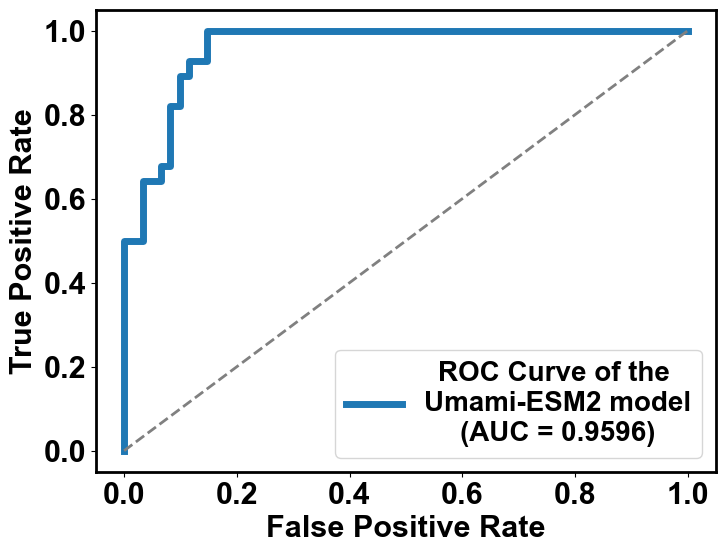

In [13]:

# --- 1. 全局字体与绘图设置 (Arial, Bold, Size 22) ---
# 为了保证样式完全一致，这里重新声明一次全局设置
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold' # 坐标轴标签加粗
plt.rcParams['font.size'] = 22

# --- 2. 绘图 ---
fpr, tpr, _ = roc_curve(all_test_labels, all_test_scores)

# 设置画布大小 (与 Five_fold 脚本一致)
plt.figure(figsize=(8, 6))

# 绘制 ROC 曲线
# 使用 Five_fold 脚本中 Mean ROC 的样式 (蓝色实线，线宽5)
# 或者您也可以选择 custom_colors 列表中的某一个颜色
mean_color = "#1F78B4" # Five_fold 脚本中使用的深蓝色
plt.plot(fpr, tpr, 
         color=mean_color, 
         linestyle='-', 
         lw=5, 
         label=f'ROC Curve of the \nUmami-ESM2 model\n(AUC = {final_auc:.4f})')

# 绘制对角线
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')


# 设置坐标轴范围
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])

# 设置标签 (字体大小22，加粗)
plt.xlabel('False Positive Rate', fontsize=22, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=22, fontweight='bold')

# 设置刻度字体 (字体大小22，加粗)
plt.xticks(fontsize=22, fontweight='bold')
plt.yticks(fontsize=22, fontweight='bold')

# 设置图例 (Arial, Bold, Size 20)
leg = plt.legend(loc="lower right", 
                 fontsize=20, 
                 labelspacing=0.8,
                 prop={'family': 'Arial', 'weight': 'bold', 'size': 20})

# 2. 遍历图例中的所有文本对象，手动设置居中
for text in leg.get_texts():
    text.set_horizontalalignment('center')
# 加粗边框 (学术风格)
ax = plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)

# --- 3. 保存图片 ---
# 指定保存目录
save_dir = r'E:\LLM+XWT\实验结果'
# 确保目录存在
os.makedirs(save_dir, exist_ok=True)

# 拼接文件名
save_path = os.path.join(save_dir, 'UmamiESM6Model_UMP442_IND_ROC_Curve_Optimal_Weighted_Styled.pdf')

# 保存并显示
plt.savefig(save_path, dpi=600, bbox_inches='tight')
print(f"\nROC曲线已保存至: {save_path}")
plt.show()